# 4 — Supplementary figures

DeepMeaning grid-resolution sweep. Five source → target combinations, each at four
P21-scegram grid resolutions (88 / 96 / 128 / 157 px): the P21-scegram DM weights
applied to all three datasets, plus the two HH25 weight sets applied back to
P21-scegram.

Metric: per-image Pearson r(DMM map, HMM) — the same measure as Figure 2 in
`3_paper_plots.ipynb`, taken against the human meaning maps of whichever dataset the
DMM maps were evaluated on. Source maps come from
`results/DeepMeaning_patch_size/{source}__to__{target}/maps_combined_raw/`.

Figures are written to `results/paper_plots/supplementary/`.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.map_comparison import SaliencyComparator
from src.stats_utils import mean_r_ci, fmt_p, clean_style

## Configuration

| Group | DM weights trained on | Evaluated on | HMM reference | Directory |
|---|---|---|---|---|
| `own_P21` | `p21_{res}` (matching resolution) | `P21_scegram` | `P21_scegram/meaning_ncb` | `p21_{res}__to__p21_{res}` |
| `indoor_to_P21` | `hh25_indoor` | `P21_scegram` | `P21_scegram/meaning_ncb` | `hh25_indoor__to__p21_{res}` |
| `outdoor_to_P21` | `hh25_outdoor` | `P21_scegram` | `P21_scegram/meaning_ncb` | `hh25_outdoor__to__p21_{res}` |
| `P21_to_indoor` | `p21_{res}` | `HH25_indoor` | `HH25_indoor/meaning_ncb` | `p21_{res}__to__hh25_indoor` |
| `P21_to_outdoor` | `p21_{res}` | `HH25_outdoor` | `HH25_outdoor/meaning_ncb` | `p21_{res}__to__hh25_outdoor` |

Only the P21-scegram side of a pair carries a grid resolution — the HH25 grids are
fixed — so the sweep varies the P21 grid whether P21 is the training source or the
evaluation target. n differs by target: 36 images for `P21_scegram`, 140 for
`HH25_indoor`, 142 for `HH25_outdoor`.

In [2]:
# --- Grid resolutions -------------------------------------------------------
RESOLUTIONS = [88, 96, 128, 157]

# --- Source data (patch-size sweep) -----------------------------------------
DEEPMEANING_ROOT = "results/DeepMeaning_patch_size"

# --- Groups: (group_key, dataset, source_tmpl, target_tmpl, x-axis label) ---
# source_tmpl / target_tmpl are the two halves of the "{source}__to__{target}"
# directory name; "{res}" in either is filled with the grid resolution. Only the
# P21-scegram side of a pair carries a resolution (the HH25 grids are fixed), so
# the sweep varies the P21 grid in both directions. `dataset` is the evaluation
# target and supplies both the images and the meaning_ncb reference.
GROUPS = [
    ("own_P21",        "P21_scegram",  "p21_{res}",    "p21_{res}",    "P21-scegram to\nP21-scegram"),
    ("indoor_to_P21",  "P21_scegram",  "hh25_indoor",  "p21_{res}",    "HH25-indoor to\nP21-scegram"),
    ("outdoor_to_P21", "P21_scegram",  "hh25_outdoor", "p21_{res}",    "HH25-outdoor to\nP21-scegram"),
    ("P21_to_indoor",  "HH25_indoor",  "p21_{res}",    "hh25_indoor",  "P21-scegram to\nHH25-indoor"),
    ("P21_to_outdoor", "HH25_outdoor", "p21_{res}",    "hh25_outdoor", "P21-scegram to\nHH25-outdoor"),
]

def deepmeaning_pair_dir(source_tmpl, target_tmpl, res):
    """Directory name for a (group, resolution) cell under DEEPMEANING_ROOT."""
    return f"{source_tmpl.format(res=res)}__to__{target_tmpl.format(res=res)}"

# --- Colours per resolution -------------------------------------------------
# Deliberately different hue families from DATASET_COLORS in 3_paper_plots.ipynb
# (red/blue/green), since both palettes can appear together in the paper.
RESOLUTION_COLORS = {
    88:  "#7B5EA7",   # violet
    96:  "#C0568C",   # magenta
    128: "#D9A441",   # amber
    157: "#4C7A7A",   # teal-gray
}

HISTOGRAM_MATCH = False

# Output directory
publication_output = "results/paper_plots/supplementary/"
os.makedirs(publication_output, exist_ok=True)

print("Resolutions:", RESOLUTIONS)
print("Groups:")
for gk, ds, src, tgt, lbl in GROUPS:
    dirs = ", ".join(deepmeaning_pair_dir(src, tgt, r) for r in RESOLUTIONS)
    print(f"  {gk}: eval on {ds}  <- {dirs}")
print(f"Output: {publication_output}")

Resolutions: [88, 96, 128, 157]
Groups:
  own_P21: eval on P21_scegram  <- p21_88__to__p21_88, p21_96__to__p21_96, p21_128__to__p21_128, p21_157__to__p21_157
  indoor_to_P21: eval on P21_scegram  <- hh25_indoor__to__p21_88, hh25_indoor__to__p21_96, hh25_indoor__to__p21_128, hh25_indoor__to__p21_157
  outdoor_to_P21: eval on P21_scegram  <- hh25_outdoor__to__p21_88, hh25_outdoor__to__p21_96, hh25_outdoor__to__p21_128, hh25_outdoor__to__p21_157
  P21_to_indoor: eval on HH25_indoor  <- p21_88__to__hh25_indoor, p21_96__to__hh25_indoor, p21_128__to__hh25_indoor, p21_157__to__hh25_indoor
  P21_to_outdoor: eval on HH25_outdoor  <- p21_88__to__hh25_outdoor, p21_96__to__hh25_outdoor, p21_128__to__hh25_outdoor, p21_157__to__hh25_outdoor
Output: results/paper_plots/supplementary/


In [3]:
# --- Journal figure sizing (same full width as 3_paper_plots.ipynb) ---------
# Was 95 mm (half width) while the sweep had three groups; five groups x four
# resolutions need the full 190 mm column to stay legible.
MM_PER_INCH   = 25.4
FIG_WIDTH_MM  = 190.0                        # same width as Figs 1-3
FIG_HEIGHT_MM = 85.0
FIG_WIDTH_IN  = FIG_WIDTH_MM / MM_PER_INCH

def mm_to_in(mm):
    return mm / MM_PER_INCH

BASE_FONTSIZE = 7                            # same base as 3_paper_plots.ipynb

DOT_INDIVIDUAL = 9                           # jittered per-image dots (same as Figs 2/3)
DOT_GROUP      = 22                          # median marker (same as Figs 2/3)

plt.rcParams.update({
    "savefig.dpi":      500,
    "figure.dpi":       500,
    "font.size":        BASE_FONTSIZE + 2,
    "axes.titlesize":   BASE_FONTSIZE + 2,
    "axes.labelsize":   BASE_FONTSIZE + 2,
    "xtick.labelsize":  BASE_FONTSIZE + 2,
    "ytick.labelsize":  BASE_FONTSIZE + 2,
    "legend.fontsize":  BASE_FONTSIZE + 2,
    "figure.titlesize": BASE_FONTSIZE + 2,
    "savefig.bbox":     None,   # NEVER 'tight' — it would change the fixed width
})

print(f"Fixed figure size: {FIG_WIDTH_MM:.0f} x {FIG_HEIGHT_MM:.0f} mm = "
      f"{FIG_WIDTH_IN:.3f} x {mm_to_in(FIG_HEIGHT_MM):.3f} in")
print(f"Base font size   : {BASE_FONTSIZE} pt")

Fixed figure size: 190 x 85 mm = 7.480 x 3.346 in
Base font size   : 7 pt


## Data loading

For each (group, resolution) cell: load the DMM maps and compute per-image
Pearson r against the P21-scegram human meaning maps.

In [4]:
# supp_data[group_key][resolution] = np.array of per-image correlations, or None
supp_data = {gk: {} for gk, *_ in GROUPS}

for group_key, dataset, source_tmpl, target_tmpl, _ in GROUPS:
    mm_dir = f"data/{dataset}/maps/meaning_ncb"
    print(f"\n{group_key} (evaluated on {dataset})")
    for res in RESOLUTIONS:
        pair_dir = deepmeaning_pair_dir(source_tmpl, target_tmpl, res)
        ai_dir   = os.path.join(DEEPMEANING_ROOT, pair_dir, "maps_combined_raw")
        if not os.path.isdir(ai_dir) or not os.path.isdir(mm_dir):
            print(f"  {res}px: MISSING (ai_dir={ai_dir})")
            supp_data[group_key][res] = None
            continue
        try:
            comp = SaliencyComparator(
                image_dir=f"data/{dataset}/images",
                map_configs={"mm": mm_dir, "aimm": ai_dir},
            )
            comp.load_data()
            comp.compute_correlations(
                histogram_match=HISTOGRAM_MATCH,
                aggregation_method="median",
            )
            vals = []
            for corr_df in comp.all_correlations.values():
                if "mm" in corr_df.index and "aimm" in corr_df.columns:
                    v = corr_df.loc["mm", "aimm"]
                elif "aimm" in corr_df.index and "mm" in corr_df.columns:
                    v = corr_df.loc["aimm", "mm"]
                else:
                    v = np.nan
                if not np.isnan(v):
                    vals.append(v)
            arr = np.array(vals) if vals else None
            supp_data[group_key][res] = arr
            med = np.median(arr) if arr is not None else float("nan")
            print(f"  {res}px: n={len(vals)}, median={med:.3f}")
        except Exception as e:
            print(f"  {res}px: ERROR — {e}")
            supp_data[group_key][res] = None

print("\nData loading complete.")


own_P21 (evaluated on P21_scegram)
SaliencyComparator initialized successfully
Image directory: data/P21_scegram/images
Map types: ['mm', 'aimm']
Loading 36 common images...


Successfully loaded data for 36 images
Data loaded for 36 images
Computing pearson correlations with histogram_match=False, aggregation=median...


Correlations computed for 36 images using median
  88px: n=36, median=0.834
SaliencyComparator initialized successfully
Image directory: data/P21_scegram/images
Map types: ['mm', 'aimm']
Loading 36 common images...


Successfully loaded data for 36 images
Data loaded for 36 images
Computing pearson correlations with histogram_match=False, aggregation=median...


Correlations computed for 36 images using median
  96px: n=36, median=0.844
SaliencyComparator initialized successfully
Image directory: data/P21_scegram/images
Map types: ['mm', 'aimm']
Loading 36 common images...


...

Correlations computed for 142 images using median
  96px: n=142, median=0.650
SaliencyComparator initialized successfully
Image directory: data/HH25_outdoor/images
Map types: ['mm', 'aimm']
Loading 142 common images...


Successfully loaded data for 142 images
Data loaded for 142 images
Computing pearson correlations with histogram_match=False, aggregation=median...


Correlations computed for 142 images using median
  128px: n=142, median=0.661
SaliencyComparator initialized successfully
Image directory: data/HH25_outdoor/images
Map types: ['mm', 'aimm']
Loading 142 common images...


Successfully loaded data for 142 images
Data loaded for 142 images
Computing pearson correlations with histogram_match=False, aggregation=median...


Correlations computed for 142 images using median
  157px: n=142, median=0.658

Data loading complete.


## Resolution comparison

Five groups on the x-axis, one per source → target combination; four violins per
group, one per P21-scegram grid resolution. Violin bodies are grey and colour
identifies the resolution, matching the convention in `3_paper_plots.ipynb`.

Saved -> results/paper_plots/supplementary/figS1_resolution_comparison_violin.png


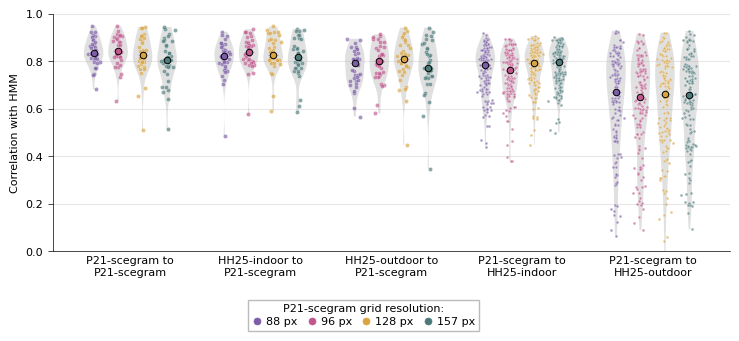

Supplementary figure size: 190.0 x 85.0 mm


In [5]:
from matplotlib.lines import Line2D

def plot_resolution_comparison(
    supp_data,
    groups,
    resolutions,
    resolution_colors,
    central_tendency="median",
    inner_gap=0.30,
    group_sep=0.70,
    figsize=None,
    ylim=(0, 1),
    ylabel="Correlation with HMM",
    dot_individual=DOT_INDIVIDUAL,
    dot_group=DOT_GROUP,
    base_fontsize=BASE_FONTSIZE,
    save_path=None,
):
    """Violin plot comparing four grid resolutions across the source→target groups.

    Each group is one source→target combination; each violin is one P21-scegram
    grid resolution. Violin bodies are grey (as in Figure 2) and colour identifies
    the resolution via the jittered dots, median dots and legend swatches only.
    """
    label_fontsize = base_fontsize + 1   # one size for every text element

    n_res    = len(resolutions)
    group_width  = (n_res - 1) * inner_gap
    group_spacing = group_width + group_sep

    positions = {}   # (group_key, res) -> x position
    group_centers = []
    for i, (group_key, *_) in enumerate(groups):
        gc = i * group_spacing
        group_centers.append(gc)
        for j, res in enumerate(resolutions):
            positions[(group_key, res)] = gc + (j - (n_res - 1) / 2) * inner_gap

    flat_items = [
        (gk, res, supp_data[gk][res], positions[(gk, res)])
        for gk, *_ in groups
        for res in resolutions
    ]
    valid_items = [(gk, res, v, p) for gk, res, v, p in flat_items
                   if v is not None and len(v) > 0]

    if figsize is None:
        figsize = (FIG_WIDTH_IN, mm_to_in(FIG_HEIGHT_MM))

    fig, ax = plt.subplots(figsize=figsize)

    if valid_items:
        data_arrays    = [v for _, _, v, _ in valid_items]
        viol_positions = [p for _, _, _, p in valid_items]

        parts = ax.violinplot(
            data_arrays,
            positions=viol_positions,
            widths=inner_gap * 0.80,
            showmeans=False,
            showmedians=True,
            showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor("lightgray")
            pc.set_alpha(0.7)
        if "cmedians" in parts:
            parts["cmedians"].set_edgecolor("#A0A0A0")
            parts["cmedians"].set_linewidth(0.5)

        rng = np.random.default_rng(42)
        for gk, res, vals, pos in valid_items:
            color = resolution_colors[res]
            # The HH25 targets carry ~4x as many images as P21-scegram; shrink
            # their dots so the violin body stays readable.
            s = dot_individual if len(vals) <= 60 else dot_individual * 0.45
            xj = rng.normal(pos, 0.035, len(vals))
            ax.scatter(xj, vals, color=color, alpha=0.65, s=s,
                       edgecolors="white", linewidth=0.25, zorder=3)
            ct = np.median(vals) if central_tendency == "median" else np.mean(vals)
            ax.scatter([pos], [ct], color=color, s=dot_group,
                       edgecolors="black", linewidth=0.7, zorder=5)

    group_labels = [g[-1] for g in groups]
    ax.set_xticks(group_centers)
    ax.set_xticklabels(group_labels, fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.tick_params(axis="y", labelsize=label_fontsize)
    ax.tick_params(axis="x", length=0)
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3, axis="y")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    # Legend: same boxed, circular-swatch style as Figure 2. Keep it inside the
    # figure — savefig runs with bbox_inches=None, so anything below y=0 is lost.
    legend_handles = [
        Line2D([], [], linestyle="none", marker="o", markersize=5,
               markerfacecolor=resolution_colors[res], markeredgecolor=resolution_colors[res],
               markeredgewidth=0.5, label=f"{res} px")
        for res in resolutions
    ]
    fig.legend(
        handles=legend_handles, title="P21-scegram grid resolution:",
        loc="lower center", bbox_to_anchor=(0.5, 0.005),
        ncol=len(legend_handles), frameon=True, framealpha=1.0,
        edgecolor="#bbbbbb", fancybox=False, borderpad=0.35,
        handletextpad=0.3, columnspacing=0.8, labelspacing=0.3,
        handlelength=1.0, fontsize=label_fontsize, title_fontsize=label_fontsize,
    )

    fig.subplots_adjust(left=0.085, right=0.99, top=0.97, bottom=0.26)
    if save_path:
        fig.savefig(save_path, dpi=500, bbox_inches=None)
        print(f"Saved -> {save_path}")
    return fig, ax


with plt.rc_context({
    "axes.linewidth":     0.5,
    "xtick.major.width":  0.5,
    "ytick.major.width":  0.5,
}):
    fig_supp, ax_supp = plot_resolution_comparison(
        supp_data=supp_data,
        groups=GROUPS,
        resolutions=RESOLUTIONS,
        resolution_colors=RESOLUTION_COLORS,
        central_tendency="median",
        ylim=(0, 1),
        ylabel="Correlation with HMM",
        save_path=os.path.join(publication_output, "figS1_resolution_comparison_violin.png"),
    )
plt.show()

_w_in, _h_in = fig_supp.get_size_inches()
print(f"Supplementary figure size: {_w_in * MM_PER_INCH:.1f} x {_h_in * MM_PER_INCH:.1f} mm")

### Statistics

Median raw r and mean [95% CI] after Fisher r→z→r, per group × resolution.

In [6]:
# --- Median and mean [95% CI] per group x resolution ------------------------
col_tuples = (
    [("n", "")] +
    [("Median (raw r)", f"{res} px") for res in RESOLUTIONS] +
    [("Mean [95% CI] (r→z→r)", f"{res} px") for res in RESOLUTIONS]
)
col_mi = pd.MultiIndex.from_tuples(col_tuples, names=["Statistic", "Resolution"])

records = []
row_labels = []
for group_key, dataset, source_tmpl, target_tmpl, lbl in GROUPS:
    row_labels.append(lbl.replace("\n", " "))
    ns = {len(v) for v in supp_data[group_key].values() if v is not None}
    row = ["/".join(str(n) for n in sorted(ns)) if ns else "—"]
    for res in RESOLUTIONS:
        vals = supp_data[group_key][res]
        row.append(f"{float(np.median(vals)):.2f}" if (vals is not None and len(vals)) else "—")
    for res in RESOLUTIONS:
        vals = supp_data[group_key][res]
        if vals is not None and len(vals) >= 2:
            mr, lo, hi = mean_r_ci(vals)
            row.append(f"{mr:.2f} [{lo:.2f}, {hi:.2f}]")
        else:
            row.append("N/A")
    records.append(row)

df_stats = pd.DataFrame(records, index=row_labels, columns=col_mi)
df_stats.index.name = "Source → target"
display(clean_style(df_stats).format(na_rep="—"))

#### Transformed values only

In [7]:
col_tuples_t = [("Mean [95% CI] (r→z→r)", f"{res} px") for res in RESOLUTIONS]
col_mi_t = pd.MultiIndex.from_tuples(col_tuples_t, names=["Statistic", "Resolution"])

records_t = []
for group_key, *_ in GROUPS:
    row = []
    for res in RESOLUTIONS:
        vals = supp_data[group_key][res]
        if vals is not None and len(vals) >= 2:
            mr, lo, hi = mean_r_ci(vals)
            row.append(f"{mr:.3f} [{lo:.3f}, {hi:.3f}]")
        else:
            row.append("N/A")
    records_t.append(row)

df_stats_t = pd.DataFrame(records_t, index=row_labels, columns=col_mi_t)
df_stats_t.index.name = "Source → target"
display(clean_style(df_stats_t).format(na_rep="—"))

### Pairwise resolution comparisons

All six pairs of grid resolutions within each group (Wilcoxon signed-rank);
p-values Bonferroni-corrected across the six pairs per group.

In [8]:
from itertools import combinations
from scipy.stats import wilcoxon, rankdata

def wilcoxon_signed_z(a, b):
    """Wilcoxon signed-rank test returning (W, z, p); z is signed (positive = a > b)."""
    d = np.asarray(a, float) - np.asarray(b, float)
    d = d[d != 0]
    n = len(d)
    if n < 2:
        return np.nan, np.nan, np.nan
    ranks = rankdata(np.abs(d))
    T_plus = ranks[d > 0].sum()
    mu = n * (n + 1) / 4
    sigma = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)
    z = (T_plus - mu) / sigma
    stat, p = wilcoxon(a, b)
    return stat, z, p

pairs = list(combinations(RESOLUTIONS, 2))
pair_labels = [f"{a} vs {b} px" for a, b in pairs]
n_pairs = len(pairs)  # 6 for 4 resolutions

records_w = []
row_labels_w = []

for group_key, dataset, source_tmpl, target_tmpl, lbl in GROUPS:
    row_labels_w.append(lbl.replace("\n", " "))
    row = []
    for a, b in pairs:
        va = supp_data[group_key][a]
        vb = supp_data[group_key][b]
        if (va is not None and vb is not None
                and len(va) == len(vb) and len(va) >= 2):
            stat, z, p = wilcoxon_signed_z(va, vb)
            p_bonf = min(p * n_pairs, 1.0)
            row.append(f"W={stat:.0f}, z={z:+.2f}\np={fmt_p(p)} (adj: {fmt_p(p_bonf)})")
        else:
            row.append("N/A")
    records_w.append(row)

df_wilcox = pd.DataFrame(records_w, index=row_labels_w, columns=pair_labels)
df_wilcox.index.name = "Source → target"
display(clean_style(df_wilcox))

,88 vs 96 px,88 vs 128 px,88 vs 157 px,96 vs 128 px,96 vs 157 px,128 vs 157 px
Source → target,,,,,,
P21-scegram to P21-scegram,"W=282, z=-0.80 p=0.4321 (adj: 1.0000)","W=245, z=+1.38 p=0.1713 (adj: 1.0000)","W=105, z=+3.58 p=0.0002 (adj: 0.0010)","W=196, z=+2.15 p=0.0308 (adj: 0.1848)","W=94, z=+3.75 p=< 0.0001 (adj: 0.0004)","W=108, z=+3.53 p=0.0002 (adj: 0.0013)"
HH25-indoor to P21-scegram,"W=25, z=-4.84 p=< 0.0001 (adj: < 0.0001)","W=172, z=-2.53 p=0.0105 (adj: 0.0627)","W=312, z=-0.33 p=0.7503 (adj: 1.0000)","W=311, z=+0.35 p=0.7386 (adj: 1.0000)","W=184, z=+2.34 p=0.0183 (adj: 0.1100)","W=133, z=+3.14 p=0.0012 (adj: 0.0072)"
HH25-outdoor to P21-scegram,"W=62, z=-4.26 p=< 0.0001 (adj: < 0.0001)","W=124, z=-3.28 p=0.0007 (adj: 0.0040)","W=288, z=-0.71 p=0.4891 (adj: 1.0000)","W=247, z=-1.35 p=0.1814 (adj: 1.0000)","W=219, z=+1.79 p=0.0743 (adj: 0.4460)","W=93, z=+3.77 p=< 0.0001 (adj: 0.0004)"
P21-scegram to HH25-indoor,"W=2487, z=+5.09 p=< 0.0001 (adj: < 0.0001)","W=3307, z=-3.39 p=0.0007 (adj: 0.0042)","W=2872, z=-4.29 p=< 0.0001 (adj: 0.0001)","W=1670, z=-6.79 p=< 0.0001 (adj: < 0.0001)","W=1985, z=-6.14 p=< 0.0001 (adj: < 0.0001)","W=3888, z=-2.18 p=0.0294 (adj: 0.1765)"
P21-scegram to HH25-outdoor,"W=4462, z=+1.25 p=0.2108 (adj: 1.0000)","W=3915, z=+2.37 p=0.0180 (adj: 0.1081)","W=4659, z=+0.85 p=0.3952 (adj: 1.0000)","W=4892, z=+0.38 p=0.7071 (adj: 1.0000)","W=4784, z=-0.60 p=0.5514 (adj: 1.0000)","W=4659, z=-0.85 p=0.3952 (adj: 1.0000)"
